# Assignment 3: Convolutional Neural Networks (50 marks total)
### Due: October 17 at 11:59pm

### Name: Al Farhana Siddique (30157968)

The goal of this assignment is to apply Convolutional Neural Networks (CNNs) in PyTorch for image classification.

## Part 1: MLP vs. CNN

### Step 0: Import Libraries

In [173]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Data Loading & Preprocessing (11 marks)

This assignment will use the CIFAR-10 dataset (*available via torchvision.datasets*). CIFAR-10 is a smaller version of the ImageNet dataset, that contains 60,000 32×32 color images in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

The first step is to define the transformations for the training and testing datasets. In this case, we will apply a random horizontal flip. Apply any other transformations that are required.

In [174]:
# TODO: define transforms for train and test sets (2 marks)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

The next step is to load the training and testing datasets and split the training data into training and validation sets. You can consider 20% of the training dataset will be used for validation. You can use a batch size of 64 for all the datasets.

In [175]:
# TODO: Load Datasets (1 mark)
training_data = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform,
)

# TODO: Split train into train + validation (1 mark)
train_size = int(0.8 * len(training_data))
val_size = len(training_data) - train_size
train_dataset, val_dataset = random_split(
    training_data,[train_size, val_size],
)

# TODO: Data loaders (1 mark)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


For this assignment, we will compare the performance of a feed-forward network (MLP) with a convolutional neural network (CNN). We will need to define a separate class to represent each model.

In [176]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


Your MLP class should have the following minimum requirements:
- At least 3 layers with ReLU activations
- At least 500 hidden units per layer
- Softmax output layer for 10 classes

Print a summary of the model architecture (number of parameters, layer shapes)

In [177]:
# TODO: Define Neural Network Model (3 marks)
class NeuralNetwork(nn.Module):
    def __init__(self, in_features=32*32*3, hidden=512, num_classes=10,use_softmax = True):
        super().__init__()
        self.use_softmax = use_softmax
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model_NN  = NeuralNetwork(use_softmax = False).to(device)
print(model_NN)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)


Your CNN class should have the following minimum requirements:
- At least 3 convolutional layers with ReLU activations
  - Example output for 3 layers: 32 feature maps -> 64 feature maps -> 128 feature maps
- At least 2 max-pooling layers
- At least 1 fully connected layer before the output
- Softmax output layer for 10 classes
- Use dropout to improve generalization

Print a summary of the model architecture (number of parameters, layer shapes)

In [178]:
# TODO: Define CNN Model (3 marks)
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 1 input channel (grayscale), 32 output feature maps, 3x3 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3= nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(  128  *8* 8,128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Input shape: [batch_size, 1, 28, 28]
        x = F.relu(self.conv1(x))   # [batch, 32, 28, 28]
        x = self.pool(x)            # [batch, 64, 14, 14]
        x = F.relu(self.conv2(x))  
        x = self.pool(x)  
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)  # flatten before fully connected portion
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_CNN =CNN().to(device)
print(model_CNN)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Step 3: Define Training and Testing Loops (7 marks)

Next, you will need to define the loss criterion and the optimizer. Select an appropriate criterion. For the optimizer, use Adam with a constant learning rate of 0.001.

In [179]:
# TODO: Define loss criterion and optimizer (2 marks)
criterion = nn.CrossEntropyLoss()
optimizer_NN = optim.Adam(model_NN.parameters(), lr=0.001)
optimizer_CNN= optim.Adam(model_CNN.parameters(), lr=0.001)

Since we are evaluating the performance of two different models, we can create functions for both the training and validation loops. For each loop, you should print the average loss and the accuracy for each epoch.

In [180]:
# TODO: Training loop (3 marks)
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        batch_size = target.size(0)
        running_loss += loss.item() * batch_size
        preds = outputs.argmax(dim=1)
        correct += (preds == target).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    accuracy = correct / total
    print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Train Acc: {accuracy*100:.2f}%")
    return avg_loss, accuracy



In [181]:
# TODO: Validation loop (2 marks)
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")
    return accuracy


### Step 4: Train, Evaluate and Visualize (11 marks)

We can also create functions for plotting the training and validation losses over the epochs and for creating a confusion matrix.

In [182]:
# TODO: Create plotting functions (2 marks)
def plot_loss_curves(train_losses, val_losses=None, title="Training and Validation Loss"):
    """Plot loss curves for one or two loss series across epochs."""
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    if val_losses is not None:
        if len(val_losses) != len(train_losses):
            raise ValueError('train_losses and val_losses must be the same length.')
        plt.plot(epochs, val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, dataloader, class_names, device):
    """Compute and display a confusion matrix for model predictions."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.xticks(rotation=45)
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()



Now that we have defined our required functions, we can train, evaluate and visualize the results for both models. You can use 20 epochs for both models.

In [183]:
# TODO: Run Training and validation loops for NN (2 marks)
num_epochs = 20
nn_train_losses, nn_val_losses = [], []
nn_train_acc, nn_val_acc = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_accuracy = train(model_NN, device, train_loader, optimizer_NN , epoch)
    val_loss, val_accuracy = validate(model_NN, device, val_loader, epoch, split_name="Val")

    nn_train_losses.append(train_loss)
    nn_val_losses.append(val_loss)
    nn_train_acc.append(train_accuracy)
    nn_val_acc.append(val_accuracy)


Epoch 01 | Train Loss: 1.8203 | Train Acc: 33.94%
Epoch 01 | Val Loss: 1.6856 | Val Acc: 39.91%
Epoch 02 | Train Loss: 1.6393 | Train Acc: 41.50%
Epoch 02 | Val Loss: 1.6050 | Val Acc: 43.14%
Epoch 03 | Train Loss: 1.5526 | Train Acc: 44.45%
Epoch 03 | Val Loss: 1.5713 | Val Acc: 44.08%
Epoch 04 | Train Loss: 1.4981 | Train Acc: 46.29%
Epoch 04 | Val Loss: 1.5323 | Val Acc: 45.99%
Epoch 05 | Train Loss: 1.4442 | Train Acc: 48.09%
Epoch 05 | Val Loss: 1.4959 | Val Acc: 47.68%
Epoch 06 | Train Loss: 1.4003 | Train Acc: 49.76%
Epoch 06 | Val Loss: 1.4907 | Val Acc: 48.11%
Epoch 07 | Train Loss: 1.3667 | Train Acc: 50.83%
Epoch 07 | Val Loss: 1.4996 | Val Acc: 47.41%
Epoch 08 | Train Loss: 1.3301 | Train Acc: 52.07%
Epoch 08 | Val Loss: 1.4252 | Val Acc: 50.20%
Epoch 09 | Train Loss: 1.2982 | Train Acc: 53.20%
Epoch 09 | Val Loss: 1.4478 | Val Acc: 49.72%
Epoch 10 | Train Loss: 1.2730 | Train Acc: 54.12%
Epoch 10 | Val Loss: 1.4718 | Val Acc: 48.99%
Epoch 11 | Train Loss: 1.2347 | Train Ac

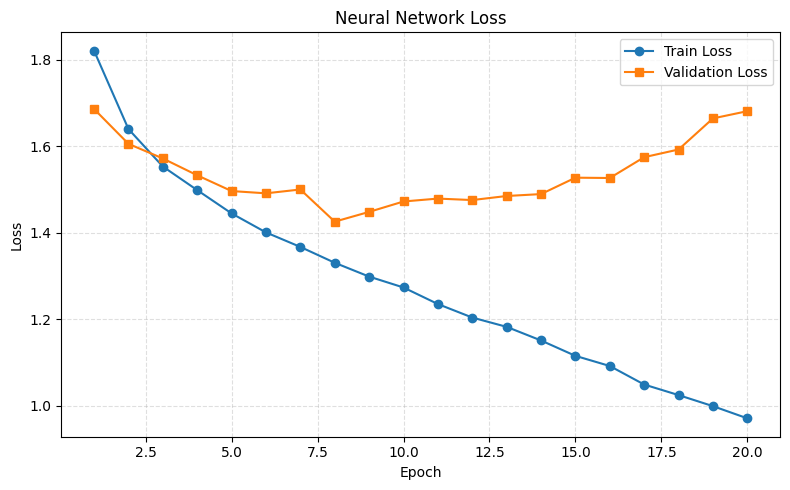

In [184]:
# TODO: Plot losses for NN (1 mark)
plot_loss_curves(nn_train_losses, nn_val_losses, title="Neural Network Loss")


In [185]:
# TODO: Run Training and validation loops for CNN (2 marks)
num_epochs_cnn = 20
cnn_train_losses, cnn_val_losses = [], []
cnn_train_acc, cnn_val_acc = [], []

for epoch in range(1, num_epochs_cnn + 1):
    train_loss, train_accuracy = train(model_CNN, device, train_loader, optimizer_CNN, epoch)
    val_loss, val_accuracy = validate(model_CNN, device, val_loader, epoch, split_name="Val")

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_train_acc.append(train_accuracy)
    cnn_val_acc.append(val_accuracy)


Epoch 01 | Train Loss: 1.4232 | Train Acc: 48.57%
Epoch 01 | Val Loss: 1.2046 | Val Acc: 58.93%
Epoch 02 | Train Loss: 1.0257 | Train Acc: 63.92%
Epoch 02 | Val Loss: 0.9347 | Val Acc: 67.07%
Epoch 03 | Train Loss: 0.8631 | Train Acc: 69.80%
Epoch 03 | Val Loss: 0.8479 | Val Acc: 70.33%
Epoch 04 | Train Loss: 0.7548 | Train Acc: 73.74%
Epoch 04 | Val Loss: 0.8010 | Val Acc: 72.45%
Epoch 05 | Train Loss: 0.6802 | Train Acc: 76.31%
Epoch 05 | Val Loss: 0.7302 | Val Acc: 74.73%
Epoch 06 | Train Loss: 0.6262 | Train Acc: 78.20%
Epoch 06 | Val Loss: 0.7394 | Val Acc: 74.40%
Epoch 07 | Train Loss: 0.5691 | Train Acc: 79.95%
Epoch 07 | Val Loss: 0.7112 | Val Acc: 75.79%
Epoch 08 | Train Loss: 0.5258 | Train Acc: 81.52%
Epoch 08 | Val Loss: 0.6934 | Val Acc: 76.48%
Epoch 09 | Train Loss: 0.4858 | Train Acc: 82.88%
Epoch 09 | Val Loss: 0.7067 | Val Acc: 76.36%
Epoch 10 | Train Loss: 0.4477 | Train Acc: 84.20%
Epoch 10 | Val Loss: 0.7362 | Val Acc: 75.84%
Epoch 11 | Train Loss: 0.4179 | Train Ac

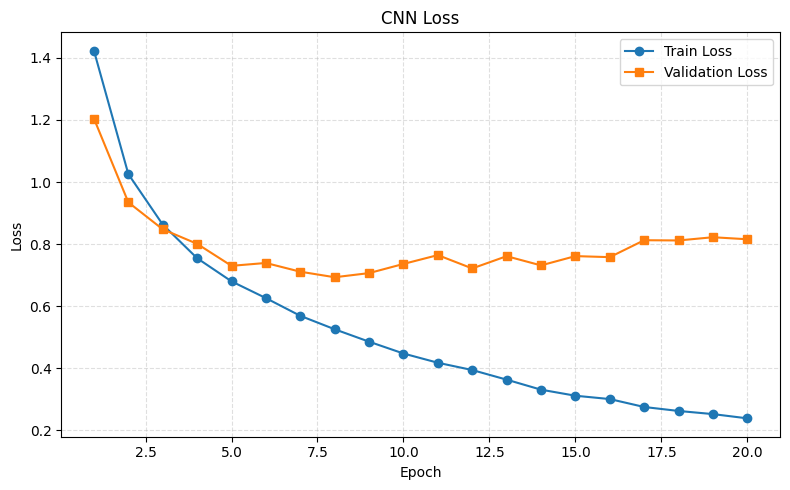

In [186]:
# TODO: Plot losses for CNN (1 mark)
plot_loss_curves(cnn_train_losses, cnn_val_losses, title="CNN Loss")


### Step 5: Model Testing (3 marks)

Now that we have compared the two models, we can select the best one and use the testing data to see how well this model generalizes.

In [187]:
# TODO: Test loop (3 marks)
def evaluate_on_test(model, device, test_loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            batch_size = target.size(0)
            running_loss += loss.item() * batch_size
            preds = outputs.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += batch_size

    avg_loss = running_loss / total
    accuracy = correct / total
    print(f"Test Loss: {avg_loss:.4f} | Test Acc: {accuracy*100:.2f}%")
    return avg_loss, accuracy

best_model = model_CNN 

num_epochs = 20
for epoch in range(1, num_epochs + 1):
    evaluate_on_test(best_model, device, test_loader)


Test Loss: 0.8318 | Test Acc: 77.59%
Test Loss: 0.8299 | Test Acc: 77.82%
Test Loss: 0.8458 | Test Acc: 77.46%
Test Loss: 0.8455 | Test Acc: 77.77%
Test Loss: 0.8297 | Test Acc: 77.76%
Test Loss: 0.8475 | Test Acc: 77.62%
Test Loss: 0.8426 | Test Acc: 77.68%
Test Loss: 0.8357 | Test Acc: 77.76%
Test Loss: 0.8341 | Test Acc: 77.60%
Test Loss: 0.8598 | Test Acc: 77.36%
Test Loss: 0.8410 | Test Acc: 77.30%
Test Loss: 0.8414 | Test Acc: 77.37%
Test Loss: 0.8452 | Test Acc: 77.58%
Test Loss: 0.8443 | Test Acc: 77.44%
Test Loss: 0.8577 | Test Acc: 77.16%
Test Loss: 0.8368 | Test Acc: 77.36%
Test Loss: 0.8353 | Test Acc: 77.80%
Test Loss: 0.8470 | Test Acc: 77.30%
Test Loss: 0.8468 | Test Acc: 77.50%
Test Loss: 0.8457 | Test Acc: 77.73%


### Questions (12 marks)
1. How do your training, validation, and test accuracies compare for your best model? What does this tell you about the model's generalization?
1. Examine your results for both models. Do you see signs of overfitting or underfitting? Explain what indicates this.
1. How can we further improve the results? Provide two suggestions.
1. If your model performs poorly on certain classes (check your confusion matrix), what does that suggest about those images or their features?
1. What is the role of dropout in the CNN? How might removing dropout change your results?
1. What other data transformations did you include and why? Are there any other data augmentation methods that we could use for this dataset?

*ANSWER HERE*

Ans 1.Best model = CNN. Final train accuracy was approxmiatly 91–92%, and validation was  77-78%, and test was around 77-78%. The small val–test gap and much larger train–val gap suggest it generalizes reasonably but still overfits some.

Ans 2.MLP exhibits classic overfitting after ~epoch 10 when the train continues to rise while the val plateaus or falls, following early underfitting (low train & val accuracy). With a drop to validation of about 14 points, CNN achieves high train accuracy, suggesting moderate overfitting but superior fit compared to the MLP. This is consistent with the bias-variance narrative: high-bias models maintain both low, whereas high-variance models have train > val.

Ans 3.To lessen variance, use more robust augmentation (such as RandomCrop with padding, ColorJitter, and RandomErasing/Cutout). Adjust the weight decay, learning-rate schedule, and/or early stopping; you can also add a batch norm or a slightly deeper CNN. These regularize without altering labels and focus on the bias–variance trade-off.

Ans 4.Classes with similar visual features are typically difficult at 32×32 resolution due to persistent confusions. Features may become less distinguishable due to background clutter and variations in pose and lighting. This implies that the model requires more discriminative features for those classes or better invariances (augmentation/architecture).

Ans 5.Dropout serves as regularization to lessen overfitting by randomly zeroing activations during training. Dropout is specifically included in the assignment "to improve generalization," which is consistent with regularization principles. If it were removed, the train–val/test gap would increase (worse generalization) but train accuracy would probably increase.

Ans 6.As specified, we employed normalization and random horizontal flip, which both add invariance to left-right flips and stabilize optimization. RandomCrop(32, padding=4), small RandomRotation, ColorJitter, and RandomErasing are additions that work well with CIFAR-10; more complex choices include MixUp/CutMix and label smoothing. Without affecting the size of the dataset, these augmentations can improve validation/test accuracy and reduce variance.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*

Ans 1.I mainly used the examples from D2L, specificlly the MNIST Example and the Cofusion Matrix example.
Ans 2. Completed in the order given in the assignment as only the next code block would work if the previous one was completed (for the most part)
Ans 3. initially i was using my cpu, but then wanted to change to cuda. i had to use gpt to figure out that some of the old code was left behind during the conversion.
Ans 4.i stuggled to get the expected outcome for the models. I also ran into an error where my def forward was calling flatten, but my model class didnt have it there. it was obvious but i didnt realize it until later

## Part 2: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*

In [ ]:
I liked that we could play around with cuda cores. Seeing how generative AI processes images was quite fascinating.